# Lecture 15 (B14): Climate economics and integrated assessment models

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §11.1-11.2 (IAMs and DICE), §11.3 (DICE with DEQNs)  
**Notebook role:** exercise  
**Original live-course source:** `lectures/day8/code/01_Climate_Exercise.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Exercise: DICE Carbon Cycle and Climate Damages

*Companion notebook to **Day 8 — Climate Economics and Deep Uncertainty Quantification** (Chapter 11 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

In this exercise, you will simulate the **DICE carbon cycle** and compute **climate damages** under different emission scenarios.

**Goals (approx. 30 min):**
1. Simulate the 3-box carbon cycle model forward in time
2. Compute temperature response and economic damages
3. Compare business-as-usual vs. mitigation policies

**No neural networks needed** — this is a pure NumPy exercise to build intuition for the climate module of DICE before studying the full CDICE/DEQN solution in Notebook 01.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13

## Background

The **DICE model** (Nordhaus, 2017) tracks CO$_2$ concentrations in three reservoirs:

| Reservoir | Description |
|-----------|-------------|
| $M_{AT}$ | Atmosphere |
| $M_{UO}$ | Upper ocean / biosphere |
| $M_{LO}$ | Lower (deep) ocean |

The carbon cycle evolves according to a **linear transition**:

$$\begin{pmatrix} M_{AT}(t+1) \\ M_{UO}(t+1) \\ M_{LO}(t+1) \end{pmatrix} = \Phi \begin{pmatrix} M_{AT}(t) \\ M_{UO}(t) \\ M_{LO}(t) \end{pmatrix} + \begin{pmatrix} E(t) \\ 0 \\ 0 \end{pmatrix}$$

where $\Phi$ is the transfer matrix and $E(t)$ are anthropogenic emissions entering the atmosphere. Temperature responds to radiative forcing from atmospheric CO$_2$, and economic **damages** are a quadratic function of temperature.

## Task 1: Simulate the Carbon Cycle (10 min)

Given the transition matrix $\Phi$ and an emissions path $E(t)$, iterate the carbon cycle forward for 30 time steps (150 years at 5-year intervals).

Plot the evolution of **atmospheric CO$_2$** ($M_{AT}$) over time.

In [2]:
# Carbon cycle transition matrix (5-year time steps)
Phi = np.array([
    [0.912, 0.0444, 0.0],
    [0.088, 0.9055, 0.0033],
    [0.0,   0.0501, 0.9967]
])

# Initial conditions (year 2015, units: GtC)
M0 = np.array([851.0, 628.0, 1740.0])  # [M_AT, M_UO, M_LO]

# Emissions path (GtC per 5-year period) — business as usual
n_steps = 30
E_bau = 50.0 * np.exp(-0.01 * np.arange(n_steps) * 5)  # slowly declining

# Year labels
years = 2015 + 5 * np.arange(n_steps + 1)

In [3]:
# TODO: Simulate carbon cycle forward for n_steps periods
# M_history = np.zeros((n_steps + 1, 3))
# M_history[0] = M0
# for t in range(n_steps):
#     M_history[t+1] = Phi @ M_history[t]
#     M_history[t+1, 0] += E_bau[t]  # emissions enter atmosphere

# TODO: Plot M_AT(t) over time
# plt.plot(years, M_history[:, 0])
# plt.xlabel('Year')
# plt.ylabel('Atmospheric CO2 (GtC)')
# plt.title('Atmospheric Carbon Under BAU Emissions')

### Solution

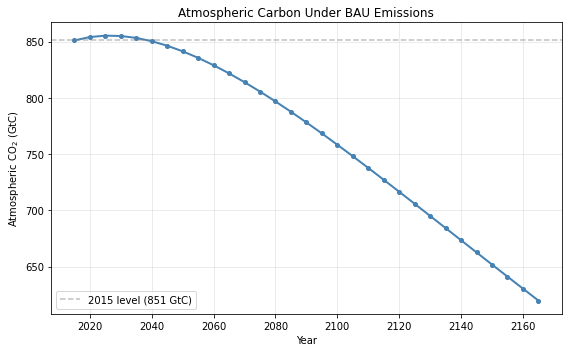

Atmospheric CO2 rises from 851 GtC in 2015
to 620 GtC in 2165.


In [4]:
# Simulate carbon cycle forward
M_history = np.zeros((n_steps + 1, 3))
M_history[0] = M0

for t in range(n_steps):
    M_history[t + 1] = Phi @ M_history[t]
    M_history[t + 1, 0] += E_bau[t]  # emissions enter atmosphere only

# Plot atmospheric CO2
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, M_history[:, 0], 'o-', color='steelblue', linewidth=2, markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Atmospheric CO$_2$ (GtC)')
ax.set_title('Atmospheric Carbon Under BAU Emissions')
ax.axhline(y=M0[0], color='gray', linestyle='--', alpha=0.5, label=f'2015 level ({M0[0]:.0f} GtC)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Atmospheric CO2 rises from {M_history[0, 0]:.0f} GtC in 2015")
print(f"to {M_history[-1, 0]:.0f} GtC in {years[-1]}.")

## Task 2: Temperature and Damages (10 min)

Now link atmospheric CO$_2$ to **temperature** and **economic damages**.

**Temperature model** (simplified single-layer):

$$T(t+1) = T(t) + \xi \left[ F(t) - \lambda \, T(t) \right] \cdot \Delta t$$

where $F(t) = \eta \cdot \log_2\!\left(\frac{M_{AT}(t)}{M_{AT,1750}}\right)$ is the radiative forcing (W/m$^2$).

**Damage function** (DICE quadratic):

$$\Omega(T) = \pi_2 \cdot T^2$$

This gives the fraction of output lost to climate damages.

In [5]:
# Temperature and damage parameters
M_AT_1750 = 588.0            # pre-industrial atmospheric CO2 (GtC)
eta = 3.8 / np.log(2)        # forcing coefficient (W/m^2 per doubling)
lam = 3.8 / 3.0              # feedback parameter (W/m^2/K)
xi = 0.015                   # temperature adjustment speed (1/yr)
pi2 = 0.00236                # damage coefficient
T0 = 1.1                     # initial warming above pre-industrial (K, circa 2015)
dt = 5.0                     # time step (years)

In [6]:
# TODO: Simulate temperature forward using M_AT from Task 1
# T_history = np.zeros(n_steps + 1)
# T_history[0] = T0
# for t in range(n_steps):
#     F = eta * np.log2(M_history[t+1, 0] / M_AT_1750)
#     T_history[t+1] = T_history[t] + xi * (F - lam * T_history[t]) * dt
#
# TODO: Compute damages as % of GDP
# damages_pct = pi2 * T_history**2 * 100
#
# TODO: Plot temperature and damages on 2 subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# ax1: temperature vs year
# ax2: damages (% GDP) vs year

### Solution

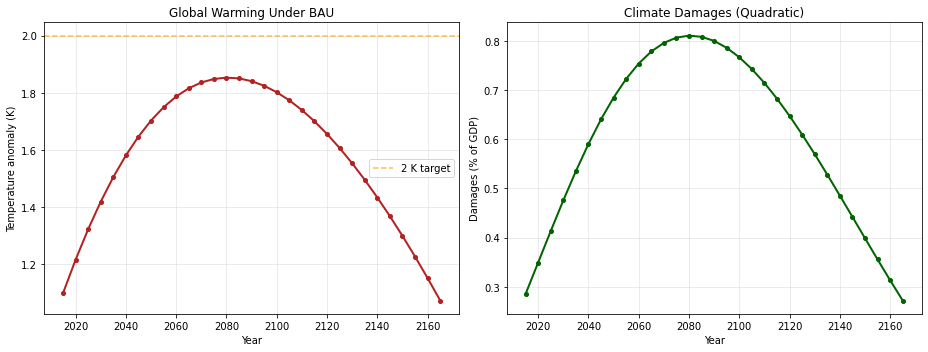

At year 2100:
  Temperature anomaly: 1.80 K
  Damages: 0.77% of GDP


In [7]:
# Simulate temperature
T_history = np.zeros(n_steps + 1)
T_history[0] = T0

for t in range(n_steps):
    F = eta * np.log2(M_history[t + 1, 0] / M_AT_1750)
    T_history[t + 1] = T_history[t] + xi * (F - lam * T_history[t]) * dt

# Compute damages as % of GDP
damages_pct = pi2 * T_history**2 * 100

# 2-panel plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: temperature
ax1.plot(years, T_history, 'o-', color='firebrick', linewidth=2, markersize=4)
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature anomaly (K)')
ax1.set_title('Global Warming Under BAU')
ax1.axhline(y=2.0, color='orange', linestyle='--', alpha=0.7, label='2 K target')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: damages
ax2.plot(years, damages_pct, 'o-', color='darkgreen', linewidth=2, markersize=4)
ax2.set_xlabel('Year')
ax2.set_ylabel('Damages (% of GDP)')
ax2.set_title('Climate Damages (Quadratic)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find year 2100 index
idx_2100 = np.argmin(np.abs(years - 2100))
print(f"At year {years[idx_2100]}:")
print(f"  Temperature anomaly: {T_history[idx_2100]:.2f} K")
print(f"  Damages: {damages_pct[idx_2100]:.2f}% of GDP")

## Task 3: Policy Comparison (10 min)

Compare **business-as-usual** (BAU) emissions with an **aggressive mitigation** scenario where emissions are halved:

$$E_{\text{mitigate}}(t) = 0.5 \cdot E_{\text{BAU}}(t)$$

Re-run the carbon cycle and temperature model for the mitigation scenario, and plot both scenarios side by side.

Compute the **avoided warming** and **avoided damages** at year 2100.

In [8]:
# TODO: Create a mitigation scenario with emissions = 0.5 * E_bau
# E_mitigate = ...

# TODO: Re-run carbon cycle + temperature for mitigation scenario
# M_mit = np.zeros((n_steps + 1, 3))
# M_mit[0] = M0
# for t in range(n_steps):
#     M_mit[t+1] = Phi @ M_mit[t]
#     M_mit[t+1, 0] += E_mitigate[t]
#
# T_mit = np.zeros(n_steps + 1)
# T_mit[0] = T0
# for t in range(n_steps):
#     F = eta * np.log2(M_mit[t+1, 0] / M_AT_1750)
#     T_mit[t+1] = T_mit[t] + xi * (F - lam * T_mit[t]) * dt

# TODO: Plot BAU vs mitigation on same axes (2 panels: CO2 and temperature)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# TODO: Compute avoided warming and avoided damages at year 2100
# idx_2100 = ...
# avoided_warming = T_history[idx_2100] - T_mit[idx_2100]
# avoided_damages = damages_pct[idx_2100] - pi2 * T_mit[idx_2100]**2 * 100

### Solution

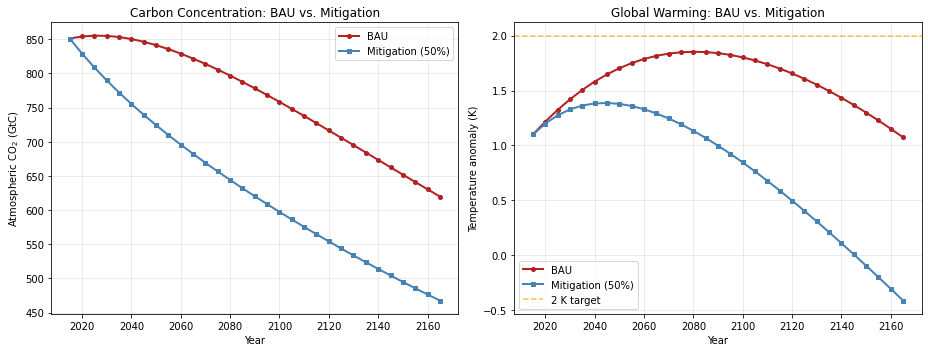


Comparison at year 2100:
  BAU temperature:        1.80 K
  Mitigation temperature: 0.85 K
  Avoided warming:        0.96 K

  BAU damages:            0.77% of GDP
  Mitigation damages:     0.17% of GDP
  Avoided damages:        0.60 pp of GDP

Halving emissions avoids 0.96 K of warming and
0.60 percentage points of GDP in damages by 2100.


In [9]:
# Mitigation scenario: halve emissions
E_mitigate = 0.5 * E_bau

# Re-run carbon cycle for mitigation
M_mit = np.zeros((n_steps + 1, 3))
M_mit[0] = M0
for t in range(n_steps):
    M_mit[t + 1] = Phi @ M_mit[t]
    M_mit[t + 1, 0] += E_mitigate[t]

# Re-run temperature for mitigation
T_mit = np.zeros(n_steps + 1)
T_mit[0] = T0
for t in range(n_steps):
    F = eta * np.log2(M_mit[t + 1, 0] / M_AT_1750)
    T_mit[t + 1] = T_mit[t] + xi * (F - lam * T_mit[t]) * dt

# Damages for mitigation
damages_mit_pct = pi2 * T_mit**2 * 100

# 2-panel comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: atmospheric CO2
ax1.plot(years, M_history[:, 0], 'o-', color='firebrick', linewidth=2,
         markersize=4, label='BAU')
ax1.plot(years, M_mit[:, 0], 's-', color='steelblue', linewidth=2,
         markersize=4, label='Mitigation (50%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Atmospheric CO$_2$ (GtC)')
ax1.set_title('Carbon Concentration: BAU vs. Mitigation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: temperature
ax2.plot(years, T_history, 'o-', color='firebrick', linewidth=2,
         markersize=4, label='BAU')
ax2.plot(years, T_mit, 's-', color='steelblue', linewidth=2,
         markersize=4, label='Mitigation (50%)')
ax2.axhline(y=2.0, color='orange', linestyle='--', alpha=0.7, label='2 K target')
ax2.set_xlabel('Year')
ax2.set_ylabel('Temperature anomaly (K)')
ax2.set_title('Global Warming: BAU vs. Mitigation')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison at year 2100
idx_2100 = np.argmin(np.abs(years - 2100))
avoided_warming = T_history[idx_2100] - T_mit[idx_2100]
avoided_damages = damages_pct[idx_2100] - damages_mit_pct[idx_2100]

print(f"\n{'='*50}")
print(f"Comparison at year {years[idx_2100]}:")
print(f"{'='*50}")
print(f"  BAU temperature:        {T_history[idx_2100]:.2f} K")
print(f"  Mitigation temperature: {T_mit[idx_2100]:.2f} K")
print(f"  Avoided warming:        {avoided_warming:.2f} K")
print(f"")
print(f"  BAU damages:            {damages_pct[idx_2100]:.2f}% of GDP")
print(f"  Mitigation damages:     {damages_mit_pct[idx_2100]:.2f}% of GDP")
print(f"  Avoided damages:        {avoided_damages:.2f} pp of GDP")
print(f"{'='*50}")
print(f"\nHalving emissions avoids {avoided_warming:.2f} K of warming and")
print(f"{avoided_damages:.2f} percentage points of GDP in damages by {years[idx_2100]}.")

## Summary

**Key takeaways from this exercise:**

1. **The carbon cycle is linear in emissions**: Atmospheric CO$_2$ accumulates proportionally to cumulative emissions, with slow diffusion into the ocean reservoirs.

2. **Temperature responds with a lag**: Even after emissions slow, temperature continues to rise because the climate system has thermal inertia ($\xi$ is small).

3. **Damages are quadratic in temperature** ($\Omega = \pi_2 T^2$): This nonlinearity is crucial — doubling the temperature more than doubles the damages. It is this convexity that makes the cost of inaction grow rapidly.

4. **Mitigation has large long-run benefits**: Halving emissions produces moderate near-term CO$_2$ reductions but significant long-run temperature and damage reductions, precisely because of the quadratic damage function.

5. **Connection to CDICE/DEQN**: In Notebook `01_Climate_Economics_DICE_DEQN.ipynb`, the social planner *optimally* chooses the mitigation rate $\mu(t)$ to balance abatement costs against avoided damages — solving the full intertemporal problem with neural networks.